In [1]:
# 1. Clone repository & install ONLY missing helper packages
!git clone https://github.com/ahsan-c0ding/S4-Enhancement-Exploration.git
%cd S4-Enhancement-Exploration
!git checkout python

import os
import sys
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# FIXED: Only install lightweight missing packages (Do NOT reinstall torch/torchvision)
%pip install einops coloredlogs torchinfo --quiet
%pip install git+https://github.com/mwalmsley/galaxy_mnist.git@c1fe9853a00bc34b2ff082585c6bb1654d34d239 --quiet

# Symlink workaround for model_params path resolving
parent_dir = os.path.dirname(current_dir)
_shim_path = os.path.join(parent_dir, "model_params")
_real_path = os.path.join(current_dir, "model_params")
if not os.path.exists(_shim_path) and os.path.exists(_real_path):
    os.symlink(_real_path, _shim_path)

Cloning into 'S4-Enhancement-Exploration'...
remote: Enumerating objects: 1152, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (146/146), done.
remote: Total 1152 (delta 88), reused 180 (delta 68), pack-reused 932 (from 2)
Receiving objects: 100% (1152/1152), 94.54 MiB | 39.37 MiB/s, done.
Resolving deltas: 100% (489/489), done.
/kaggle/working/S4-Enhancement-Exploration
Branch 'python' set up to track remote branch 'python' from 'origin'.
Switched to a new branch 'python'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from einops import repeat

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, roc_auc_score

from model.functions import load_data

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = [11, 6]

# Reproducibility -- same seed as every other run in this series, so the
# train/val split lines up exactly (the test set is fixed by load_data anyway)
RNG_SEED = 30485
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RNG_SEED)

CLASS_NAMES = ["Smooth Round", "Smooth Cigar", "Edge-on Disk", "Unbarred Spiral"]

# ============================================================================
# PRODUCTION S4D CONFIGURATION (matches the best model -- still needed here
# since both new runs below share everything except the patch embedding /
# S4D on-off switch)
# ============================================================================
COLORED = True
IN_CHANNELS = 3 if COLORED else 1

S4D_STATE = 256
S4D_NUM_LAYERS = 3
S4D_PATCH_SIZE = 4
S4D_POOLING = "last"
S4D_USE_NORM = False
S4D_USE_RESIDUAL = False
S4D_DROPOUT = 0.2
S4D_PATCH_EMBED = "conv"     # what the production / CNN-only-ablation models used

S4D_BATCH_SIZE = 32
S4D_FINAL_EPOCHS = 630
LEARNING_RATE = 1e-3

# ============================================================================
# LINEAR-PATCH-EMBED ABLATIONS -- this notebook's actual point
# ============================================================================
# The earlier ablation (S4D removed, conv stem kept) showed S4D matters a lot
# (51.50% vs 86.80%) -- but it never tested the OTHER half of the question: is
# the conv stem itself doing meaningful work, or would a trivial per-patch
# linear projection (no convolution, no pixel mixing beyond a single patch)
# do just as well once S4D is handling the sequence modeling? patch_embed="linear"
# already exists in GalaxyClassifierS4DFast for exactly this -- it flattens each
# raw 4x4x3 patch and projects it with a single nn.Linear, no convolution at all.
#
# Two runs complete the 2x2 grid (conv/linear embed x S4D on/off):
#   Linear embed + S4D on   -> isolates the conv stem's value when S4D IS present
#   Linear embed + S4D off  -> the absolute floor, for a complete picture
LINEAR_S4D_NUM_LAYERS = S4D_NUM_LAYERS   # 3 -- S4D stays on
LINEAR_S4D_POOLING = S4D_POOLING         # "last", matching the production model
LINEAR_S4D_PATCH_EMBED = "linear"

LINEAR_NOS4D_NUM_LAYERS = 0              # S4D off, same reasoning as the earlier ablation
LINEAR_NOS4D_POOLING = "mean"
LINEAR_NOS4D_PATCH_EMBED = "linear"

print(f"Device: {DEVICE}")
print(f"Reference S4D Model: {S4D_NUM_LAYERS} layers | d_model={S4D_STATE} | patch_embed={S4D_PATCH_EMBED}")
print(f"Run 1 -- Linear embed + S4D:    {LINEAR_S4D_NUM_LAYERS} layers | pooling={LINEAR_S4D_POOLING} | patch_embed={LINEAR_S4D_PATCH_EMBED}")
print(f"Run 2 -- Linear embed + no S4D: {LINEAR_NOS4D_NUM_LAYERS} layers | pooling={LINEAR_NOS4D_POOLING} | patch_embed={LINEAR_NOS4D_PATCH_EMBED}")


/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Device: cuda
Reference S4D Model: 3 layers | d_model=256 | patch_embed=conv
Run 1 -- Linear embed + S4D:    3 layers | pooling=last | patch_embed=linear
Run 2 -- Linear embed + no S4D: 0 layers | pooling=mean | patch_embed=linear


In [3]:
class HilbertScan(nn.Module):
    """Reorders patches of a (B, C, H, W) image along a Hilbert curve."""
    def __init__(self, image_size=64, patch_size=1):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2
        self.register_buffer("indices", self._get_hilbert_indices(self.grid_size))

    @staticmethod
    def _rot(s, x, y, rx, ry):
        if ry == 0:
            if rx == 1:
                x = s - 1 - x
                y = s - 1 - y
            x, y = y, x
        return x, y

    def _d2xy(self, n, d):
        x = y = 0
        t, s = d, 1
        while s < n:
            rx = (t // 2) & 1
            ry = (t ^ rx) & 1
            x, y = self._rot(s, x, y, rx, ry)
            x += s * rx
            y += s * ry
            t //= 4
            s *= 2
        return x, y

    def _get_hilbert_indices(self, grid_size):
        indices = []
        for d in range(grid_size * grid_size):
            x, y = self._d2xy(grid_size, d)
            indices.append(y * grid_size + x)
        return torch.LongTensor(indices)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        patches = x.unfold(2, p, p).unfold(3, p, p)
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        patches = patches.view(B, self.num_patches, C * p * p)
        return patches[:, self.indices, :]


class TakeLastTimestep(nn.Module):
    def forward(self, x):
        return x[:, -1, :]


class S4DConv(nn.Module):
    """Fast FFT-based parallel convolution S4D layer."""
    def __init__(self, d_model, d_state=64, dt_min=0.001, dt_max=0.1, transposed=True, lr=None):
        super().__init__()
        self.h = d_model
        self.n = d_state
        self.transposed = transposed

        log_dt = torch.rand(self.h) * (math.log(dt_max) - math.log(dt_min)) + math.log(dt_min)
        log_A_real = torch.log(0.5 * torch.ones(self.h, self.n // 2))
        A_imag = math.pi * repeat(torch.arange(self.n // 2), 'n -> h n', h=self.h)
        C_init = torch.randn(self.h, self.n // 2, dtype=torch.cfloat)

        self.register("log_dt", log_dt, lr)
        self.register("log_A_real", log_A_real, lr)
        self.register("A_imag", A_imag, lr)

        self.C = nn.Parameter(torch.view_as_real(C_init))
        self.D = nn.Parameter(torch.randn(self.h))

    def register(self, name, tensor, lr=None):
        if lr == 0.0:
            self.register_buffer(name, tensor)
        else:
            self.register_parameter(name, nn.Parameter(tensor))
            optim = {"weight_decay": 0.0}
            if lr is not None:
                optim["lr"] = lr
            setattr(getattr(self, name), "_optim", optim)

    def forward(self, u):
        if not self.transposed:
            u = u.transpose(-1, -2)
        L = u.size(-1)

        dt = torch.exp(self.log_dt)
        C = torch.view_as_complex(self.C)
        A = -torch.exp(self.log_A_real) + 1j * self.A_imag

        dtA = A * dt.unsqueeze(-1)
        K_exp = torch.exp(dtA.unsqueeze(-1) * torch.arange(L, device=u.device))
        C_tilde = C * (torch.exp(dtA) - 1.) / A
        k = 2 * torch.einsum('hn, hnl -> hl', C_tilde, K_exp).real

        k_f = torch.fft.rfft(k, n=2 * L)
        u_f = torch.fft.rfft(u, n=2 * L)
        y = torch.fft.irfft(u_f * k_f, n=2 * L)[..., :L]
        y = y + u * self.D.unsqueeze(-1)

        if not self.transposed:
            y = y.transpose(-1, -2)
        return y, None


class ConvPatchStem(nn.Module):
    """Convolutional stem for local neighborhood mixing before patch projection."""
    def __init__(self, in_channels, d_model, patch_size):
        super().__init__()
        mid_channels = max(in_channels * 8, 32)
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, stride=1, padding=1),
            nn.GELU(),
            nn.Conv2d(mid_channels, d_model, kernel_size=patch_size, stride=patch_size),
        )

    def forward(self, x):
        return self.net(x)


class GalaxyClassifierS4DFast(nn.Module):
    """Production S4D Classifier."""
    def __init__(self, s4_state=64, d_model=64, num_classes=4, colored=True,
                 num_layers=2, patch_size=1, pooling="last",
                 use_norm=False, use_residual=False, dropout=0.0,
                 patch_embed="linear"):
        super().__init__()
        self.hilbert_channels = 1 if not colored else 3
        self.patch_size = patch_size
        self.pooling = pooling
        self.use_norm = use_norm
        self.use_residual = use_residual
        self.patch_embed = patch_embed

        if patch_embed == "linear":
            self.hilbert_scan = HilbertScan(image_size=64, patch_size=patch_size)
            patch_dim = self.hilbert_channels * patch_size * patch_size
            self.uproject = nn.Linear(patch_dim, d_model)
            self.conv_stem = None
        elif patch_embed == "conv":
            self.conv_stem = ConvPatchStem(self.hilbert_channels, d_model, patch_size)
            self.hilbert_scan = HilbertScan(image_size=64 // patch_size, patch_size=1)
            self.uproject = nn.Identity()

        self.s4_layers = nn.ModuleList([
            S4DConv(d_model=d_model, d_state=s4_state, transposed=False)
            for _ in range(num_layers)
        ])
        self.acts = nn.ModuleList([nn.GELU() for _ in range(num_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(num_layers)]) if use_norm else None
        self.drop = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        if pooling == "last":
            self.take_last = TakeLastTimestep()
        elif pooling == "mean":
            self.take_last = None
        else:
            raise ValueError(f"Unknown pooling type {pooling}")

        self.fc = nn.Linear(d_model, num_classes)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, return_logits=True):
        if self.patch_embed == "conv":
            feat = self.conv_stem(x)
            x_seq = self.hilbert_scan(feat)
            h = self.uproject(x_seq)
        else:
            x_seq = self.hilbert_scan(x)
            h = self.uproject(x_seq)

        for i, (s4_layer, act) in enumerate(zip(self.s4_layers, self.acts)):
            residual = h
            h_in = self.norms[i](h) if self.use_norm else h
            h_out, _ = s4_layer(h_in)
            h_out = act(h_out)
            h_out = self.drop(h_out)
            h = residual + h_out if self.use_residual else h_out

        pooled = h.mean(dim=1) if self.take_last is None else self.take_last(h)
        logits = self.fc(pooled)

        if return_logits:
            return logits
        return self.softmax(logits)

In [4]:
# Load dataset
X, y_onehot, y = load_data(root="./data", download=True, train=True, colored=COLORED)
X_test, y_test_onehot, y_test = load_data(root="./data", download=True, train=False, colored=COLORED)
NUM_CLASSES = y_onehot.shape[1]

# FIXED: Unpack 4 outputs corresponding to passing X and y
x_train, x_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RNG_SEED, stratify=y
)

# Custom dataset supporting rotation and flip augmentation
class GalaxyDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        lbl = self.labels[idx]
        if self.augment:
            # Random orthogonal rotation
            k = random.randint(0, 3)
            img = torch.rot90(img, k, [1, 2])
            # Random flips
            if random.random() > 0.5:
                img = torch.flip(img, [2])
            if random.random() > 0.5:
                img = torch.flip(img, [1])
        return img, lbl

train_dataset = GalaxyDataset(x_train, y_train, augment=True)
val_dataset = GalaxyDataset(x_val, y_val, augment=False)
test_dataset = GalaxyDataset(X_test, y_test, augment=False)

train_loader = DataLoader(train_dataset, batch_size=S4D_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=S4D_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=S4D_BATCH_SIZE, shuffle=False)

print(f"Data Split -> Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

100%|██████████| 68.7M/68.7M [00:03<00:00, 17.2MB/s]
100%|██████████| 17.3M/17.3M [00:01<00:00, 16.0MB/s]


Original Dataset Size: 8000 samples
Original Dataset Size: 2000 samples
Data Split -> Train: 6400 | Val: 1600 | Test: 2000


In [5]:
def create_s4d_optimizer(model, lr=1e-3, weight_decay=0.01):
    decay_params, no_decay_params, special_params = [], [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if hasattr(param, "_optim"):
            opt_dict = param._optim
            param_lr = opt_dict.get("lr", lr)
            special_params.append({'params': [param], 'lr': param_lr, 'weight_decay': 0.0})
        elif any(k in name for k in ["bias", "norm", "LayerNorm"]):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    groups = [
        {'params': decay_params, 'weight_decay': weight_decay, 'lr': lr},
        {'params': no_decay_params, 'weight_decay': 0.0, 'lr': lr},
    ] + special_params
    return torch.optim.AdamW(groups)


def train_s4d_production(model, train_loader, val_loader, epochs=S4D_FINAL_EPOCHS, lr=LEARNING_RATE, device=DEVICE, ckpt_name="s4d_production_best.pt"):
    model.to(device)
    optimizer = create_s4d_optimizer(model, lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-5
    )
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    os.makedirs("checkpoints", exist_ok=True)
    best_ckpt_path = f"checkpoints/{ckpt_name}"  # parametrized so different runs don't clobber each other's checkpoint

    start_time = time.time()
    print(f"Starting S4D production training for {epochs} epochs...")

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images, return_logits=True)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(-1) == labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                logits = model(images, return_logits=True)
                val_correct += (logits.argmax(-1) == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_ckpt_path)

        if (epoch + 1) % 25 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} (Best: {best_val_acc:.4f})")

    elapsed = time.time() - start_time
    print(f"\nTraining completed in {elapsed/60:.2f} mins. Best Validation Accuracy: {best_val_acc*100:.2f}%")
    
    # Load best checkpoint
    model.load_state_dict(torch.load(best_ckpt_path))
    return model, history


def evaluate_on_test(model, test_loader, device=DEVICE):
    """Runs a trained model on the test set and returns every metric we report."""
    model.eval()
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            probs = model(images, return_logits=False)
            preds = probs.argmax(-1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    all_probs = np.array(all_probs)
    return {
        "accuracy": accuracy_score(all_targets, all_preds),
        "f1": f1_score(all_targets, all_preds, average="macro"),
        "precision": precision_score(all_targets, all_preds, average="macro"),
        "recall": recall_score(all_targets, all_preds, average="macro"),
        "auc": roc_auc_score(all_targets, all_probs, multi_class="ovr", average="macro"),
        "preds": all_preds,
        "targets": all_targets,
    }


In [6]:
# Run 1: swap the conv stem for a plain linear per-patch projection, keep S4D on.
linear_s4d_model = GalaxyClassifierS4DFast(
    s4_state=S4D_STATE,
    d_model=S4D_STATE,
    num_classes=NUM_CLASSES,
    colored=COLORED,
    num_layers=LINEAR_S4D_NUM_LAYERS,
    patch_size=S4D_PATCH_SIZE,
    pooling=LINEAR_S4D_POOLING,
    use_norm=S4D_USE_NORM,
    use_residual=S4D_USE_RESIDUAL,
    dropout=S4D_DROPOUT,
    patch_embed=LINEAR_S4D_PATCH_EMBED
)

best_linear_s4d_model, linear_s4d_history = train_s4d_production(
    linear_s4d_model, train_loader, val_loader,
    epochs=S4D_FINAL_EPOCHS, ckpt_name="linear_embed_s4d_best.pt"
)


Starting S4D production training for 630 epochs...
Epoch 025/630 | Train Loss: 0.6503 | Train Acc: 0.7227 | Val Acc: 0.7488 (Best: 0.7581)
Epoch 050/630 | Train Loss: 0.5950 | Train Acc: 0.7417 | Val Acc: 0.7538 (Best: 0.7594)
Epoch 075/630 | Train Loss: 0.5919 | Train Acc: 0.7450 | Val Acc: 0.7531 (Best: 0.7688)
Epoch 100/630 | Train Loss: 0.5512 | Train Acc: 0.7583 | Val Acc: 0.7725 (Best: 0.7756)
Epoch 125/630 | Train Loss: 0.5056 | Train Acc: 0.7842 | Val Acc: 0.7800 (Best: 0.7875)
Epoch 150/630 | Train Loss: 0.4967 | Train Acc: 0.7909 | Val Acc: 0.7781 (Best: 0.7875)
Epoch 175/630 | Train Loss: 0.5250 | Train Acc: 0.7716 | Val Acc: 0.7788 (Best: 0.7931)
Epoch 200/630 | Train Loss: 0.5066 | Train Acc: 0.7858 | Val Acc: 0.7900 (Best: 0.7931)
Epoch 225/630 | Train Loss: 0.4714 | Train Acc: 0.8006 | Val Acc: 0.7987 (Best: 0.8037)
Epoch 250/630 | Train Loss: 0.4544 | Train Acc: 0.8081 | Val Acc: 0.8013 (Best: 0.8037)
Epoch 275/630 | Train Loss: 0.4405 | Train Acc: 0.8111 | Val Acc: 0.8

In [7]:
# Run 2: linear patch embed AND no S4D layers -- the floor of the 2x2 grid.
linear_nos4d_model = GalaxyClassifierS4DFast(
    s4_state=S4D_STATE,
    d_model=S4D_STATE,
    num_classes=NUM_CLASSES,
    colored=COLORED,
    num_layers=LINEAR_NOS4D_NUM_LAYERS,
    patch_size=S4D_PATCH_SIZE,
    pooling=LINEAR_NOS4D_POOLING,
    use_norm=S4D_USE_NORM,
    use_residual=S4D_USE_RESIDUAL,
    dropout=S4D_DROPOUT,
    patch_embed=LINEAR_NOS4D_PATCH_EMBED
)

best_linear_nos4d_model, linear_nos4d_history = train_s4d_production(
    linear_nos4d_model, train_loader, val_loader,
    epochs=S4D_FINAL_EPOCHS, ckpt_name="linear_embed_nos4d_best.pt"
)


Starting S4D production training for 630 epochs...
Epoch 025/630 | Train Loss: 1.3249 | Train Acc: 0.3722 | Val Acc: 0.3769 (Best: 0.3787)
Epoch 050/630 | Train Loss: 1.3228 | Train Acc: 0.3730 | Val Acc: 0.3406 (Best: 0.3806)
Epoch 075/630 | Train Loss: 1.3239 | Train Acc: 0.3755 | Val Acc: 0.3756 (Best: 0.3812)
Epoch 100/630 | Train Loss: 1.3206 | Train Acc: 0.3758 | Val Acc: 0.3781 (Best: 0.3812)
Epoch 125/630 | Train Loss: 1.3167 | Train Acc: 0.3727 | Val Acc: 0.3787 (Best: 0.3812)
Epoch 150/630 | Train Loss: 1.3136 | Train Acc: 0.3830 | Val Acc: 0.3713 (Best: 0.3812)
Epoch 175/630 | Train Loss: 1.3212 | Train Acc: 0.3736 | Val Acc: 0.3731 (Best: 0.3825)
Epoch 200/630 | Train Loss: 1.3171 | Train Acc: 0.3770 | Val Acc: 0.3706 (Best: 0.3862)
Epoch 225/630 | Train Loss: 1.3182 | Train Acc: 0.3728 | Val Acc: 0.3688 (Best: 0.3887)
Epoch 250/630 | Train Loss: 1.3160 | Train Acc: 0.3745 | Val Acc: 0.3756 (Best: 0.3887)
Epoch 275/630 | Train Loss: 1.3139 | Train Acc: 0.3787 | Val Acc: 0.3

Linear Embed + S4D -- Test Set Results
Accuracy:        82.85%
Macro-F1:        0.8290
Macro-Precision: 0.8299
Macro-Recall:    0.8294
Macro-AUC (OVR): 0.9621

Linear Embed + No S4D -- Test Set Results
Accuracy:        35.85%
Macro-F1:        0.3528
Macro-Precision: 0.3613
Macro-Recall:    0.3604
Macro-AUC (OVR): 0.6195



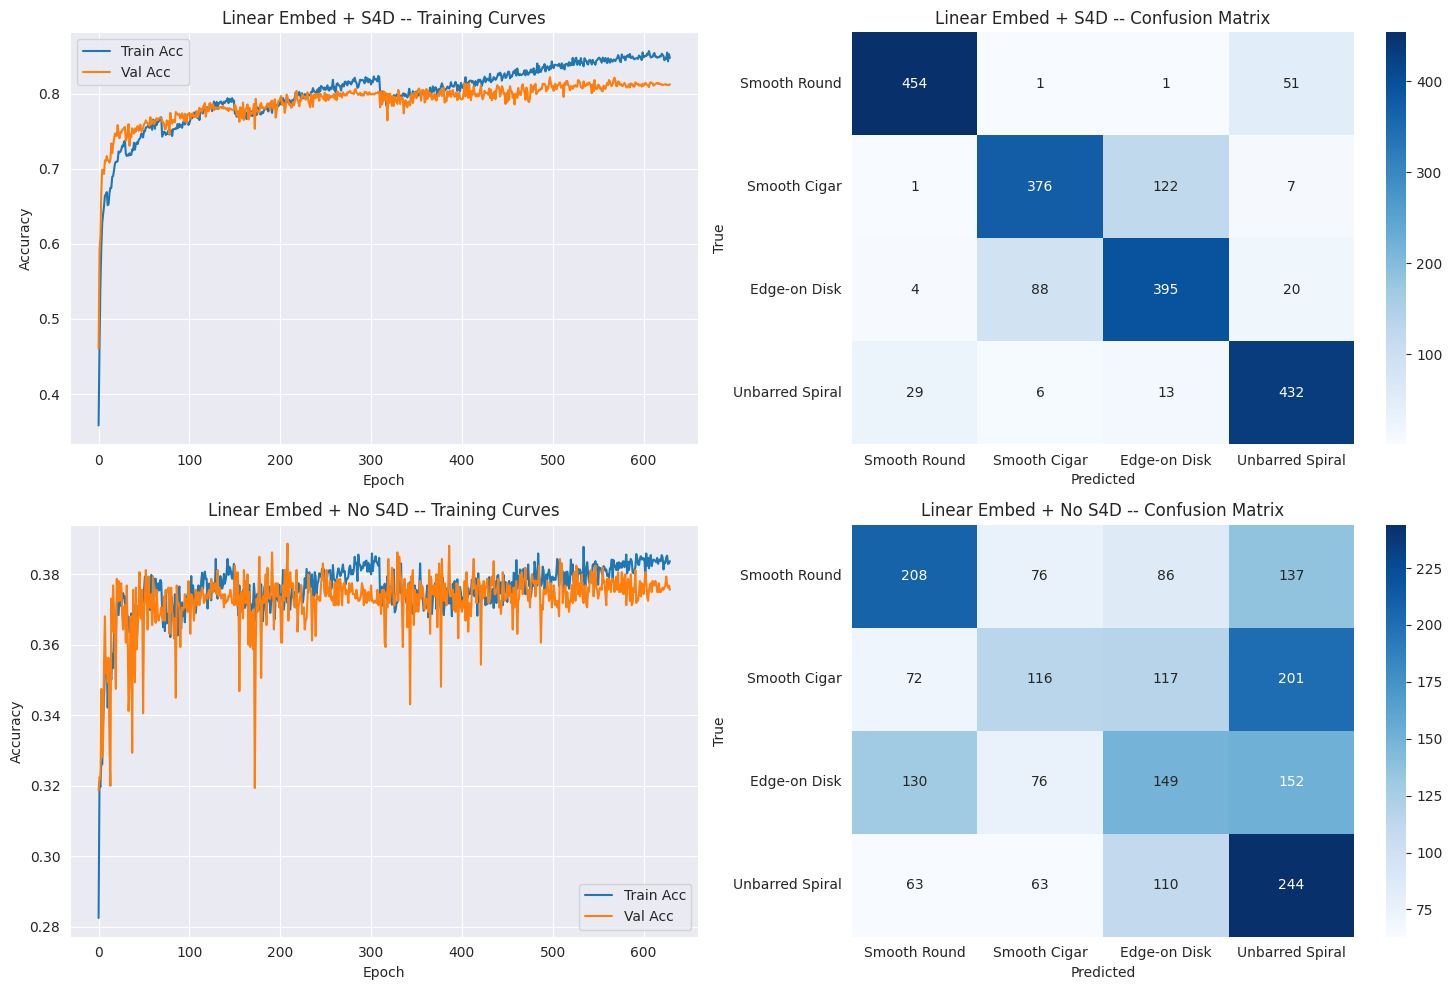

In [8]:
linear_s4d_results = evaluate_on_test(best_linear_s4d_model, test_loader)
linear_nos4d_results = evaluate_on_test(best_linear_nos4d_model, test_loader)

for name, res in [("Linear Embed + S4D", linear_s4d_results), ("Linear Embed + No S4D", linear_nos4d_results)]:
    print("=" * 50)
    print(f"{name} -- Test Set Results")
    print("=" * 50)
    print(f"Accuracy:        {res['accuracy'] * 100:.2f}%")
    print(f"Macro-F1:        {res['f1']:.4f}")
    print(f"Macro-Precision: {res['precision']:.4f}")
    print(f"Macro-Recall:    {res['recall']:.4f}")
    print(f"Macro-AUC (OVR): {res['auc']:.4f}")
    print("=" * 50)
    print()

# Training curves + confusion matrices, both runs side by side
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(linear_s4d_history["train_acc"], label="Train Acc")
axes[0, 0].plot(linear_s4d_history["val_acc"], label="Val Acc")
axes[0, 0].set_title("Linear Embed + S4D -- Training Curves")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Accuracy"); axes[0, 0].legend()

cm1 = confusion_matrix(linear_s4d_results["targets"], linear_s4d_results["preds"])
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0, 1])
axes[0, 1].set_title("Linear Embed + S4D -- Confusion Matrix")
axes[0, 1].set_xlabel("Predicted"); axes[0, 1].set_ylabel("True")

axes[1, 0].plot(linear_nos4d_history["train_acc"], label="Train Acc")
axes[1, 0].plot(linear_nos4d_history["val_acc"], label="Val Acc")
axes[1, 0].set_title("Linear Embed + No S4D -- Training Curves")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Accuracy"); axes[1, 0].legend()

cm2 = confusion_matrix(linear_nos4d_results["targets"], linear_nos4d_results["preds"])
sns.heatmap(cm2, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1, 1])
axes[1, 1].set_title("Linear Embed + No S4D -- Confusion Matrix")
axes[1, 1].set_xlabel("Predicted"); axes[1, 1].set_ylabel("True")

plt.tight_layout()
plt.show()


In [9]:
from torchinfo import summary

def count_params(model):
    return sum(p.numel() for p in model.parameters())

# The first four rows were trained in earlier notebooks -- these counts are
# copied verbatim from their verified torchinfo output. Only the two new
# models below get freshly counted.
param_counts = {
    "Best S4D (3L, d=256)": 528_004,
    "2-Layer S4D (d=256)": 396_420,
    "64x64-dim S4D (3L)": 58_948,
    "Conv Embed + No S4D": 133_252,
    "Linear Embed + S4D": count_params(best_linear_s4d_model),
    "Linear Embed + No S4D": count_params(best_linear_nos4d_model),
}

for name, n in param_counts.items():
    print(f"{name:26s} {n:>10,} params")

print("\nFull layer-by-layer breakdown -- Linear Embed + S4D:")
summary(best_linear_s4d_model, input_size=(S4D_BATCH_SIZE, IN_CHANNELS, 64, 64))

print("\nFull layer-by-layer breakdown -- Linear Embed + No S4D:")
summary(best_linear_nos4d_model, input_size=(S4D_BATCH_SIZE, IN_CHANNELS, 64, 64))


Best S4D (3L, d=256)          528,004 params
2-Layer S4D (d=256)           396,420 params
64x64-dim S4D (3L)             58,948 params
Conv Embed + No S4D           133,252 params
Linear Embed + S4D            408,324 params
Linear Embed + No S4D          13,572 params

Full layer-by-layer breakdown -- Linear Embed + S4D:

Full layer-by-layer breakdown -- Linear Embed + No S4D:


Layer (type:depth-idx)                   Output Shape              Param #
GalaxyClassifierS4DFast                  [32, 4]                   --
├─HilbertScan: 1-1                       [32, 256, 48]             --
├─Linear: 1-2                            [32, 256, 256]            12,544
├─Linear: 1-3                            [32, 4]                   1,028
Total params: 13,572
Trainable params: 13,572
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.43
Input size (MB): 1.57
Forward/backward pass size (MB): 16.78
Params size (MB): 0.05
Estimated Total Size (MB): 18.41

In [10]:
import shutil
from IPython.display import FileLink, display

ckpt_names = ["linear_embed_s4d_best.pt", "linear_embed_nos4d_best.pt"]

for ckpt_name in ckpt_names:
    source_path = f"checkpoints/{ckpt_name}"
    destination_path = f"/kaggle/working/{ckpt_name}"
    if os.path.exists(source_path):
        shutil.copy(source_path, destination_path)
        print(f"✅ {ckpt_name} moved to the root output folder!")
    else:
        print(f"❌ Could not find {ckpt_name} -- did training complete?")

print("\nClick the links below to download your weights:")
os.chdir('/kaggle/working')
for ckpt_name in ckpt_names:
    if os.path.exists(ckpt_name):
        display(FileLink(ckpt_name))
os.chdir('/kaggle/working/S4-Enhancement-Exploration')


✅ linear_embed_s4d_best.pt moved to the root output folder!
✅ linear_embed_nos4d_best.pt moved to the root output folder!

Click the links below to download your weights:


/kaggle/working/linear_embed_s4d_best.pt

/kaggle/working/linear_embed_nos4d_best.pt

In [11]:
# ============================================================================
# SUMMARY -- every run so far, plus the 2x2 grid decomposition
# ============================================================================
summary_rows = [
    {"Model": "Best S4D (3L, d=256) [conv+S4D]",   "Test/Val": "Test",
     "Accuracy": 0.8680, "Macro-F1": 0.8688, "Macro-Precision": None, "Macro-Recall": None, "Macro-AUC": None,
     "Params": param_counts["Best S4D (3L, d=256)"]},
    {"Model": "2-Layer S4D (d=256)", "Test/Val": "Test",
     "Accuracy": 0.8640, "Macro-F1": 0.8647, "Macro-Precision": None, "Macro-Recall": None, "Macro-AUC": None,
     "Params": param_counts["2-Layer S4D (d=256)"]},
    {"Model": "64x64-dim S4D (3L)", "Test/Val": "Val",
     "Accuracy": 0.8500, "Macro-F1": None, "Macro-Precision": None, "Macro-Recall": None, "Macro-AUC": None,
     "Params": param_counts["64x64-dim S4D (3L)"]},
    {"Model": "Conv Embed + No S4D [conv+meanpool]", "Test/Val": "Test",
     "Accuracy": 0.5150, "Macro-F1": 0.5156, "Macro-Precision": 0.5205, "Macro-Recall": 0.5169, "Macro-AUC": 0.7730,
     "Params": param_counts["Conv Embed + No S4D"]},
    {"Model": "Linear Embed + S4D", "Test/Val": "Test",
     "Accuracy": linear_s4d_results["accuracy"], "Macro-F1": linear_s4d_results["f1"],
     "Macro-Precision": linear_s4d_results["precision"], "Macro-Recall": linear_s4d_results["recall"],
     "Macro-AUC": linear_s4d_results["auc"], "Params": param_counts["Linear Embed + S4D"]},
    {"Model": "Linear Embed + No S4D", "Test/Val": "Test",
     "Accuracy": linear_nos4d_results["accuracy"], "Macro-F1": linear_nos4d_results["f1"],
     "Macro-Precision": linear_nos4d_results["precision"], "Macro-Recall": linear_nos4d_results["recall"],
     "Macro-AUC": linear_nos4d_results["auc"], "Params": param_counts["Linear Embed + No S4D"]},
]

summary_df = pd.DataFrame(summary_rows).set_index("Model")
summary_df["Accuracy"] = summary_df["Accuracy"].map(lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "N/A")
for col in ["Macro-F1", "Macro-Precision", "Macro-Recall", "Macro-AUC"]:
    summary_df[col] = summary_df[col].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "N/A")
summary_df["Params"] = summary_df["Params"].map(lambda x: f"{x:,}")

print(summary_df.to_string())

# ----------------------------------------------------------------------------
# 2x2 grid: conv-vs-linear embed x S4D-on-vs-off -- this is the actual answer
# to "is the conv patch embedding why the model performs well?"
# ----------------------------------------------------------------------------
conv_s4d_acc     = 0.8680
conv_nos4d_acc   = 0.5150
linear_s4d_acc   = linear_s4d_results["accuracy"]
linear_nos4d_acc = linear_nos4d_results["accuracy"]

print("\n" + "=" * 60)
print("2x2 GRID (test accuracy)")
print("=" * 60)
print(f"{'':20s}{'S4D on':>15s}{'S4D off':>15s}")
print(f"{'Conv embed':20s}{conv_s4d_acc*100:>14.2f}%{conv_nos4d_acc*100:>14.2f}%")
print(f"{'Linear embed':20s}{linear_s4d_acc*100:>14.2f}%{linear_nos4d_acc*100:>14.2f}%")

print(f"\nS4D's contribution holding conv embed fixed:    {(conv_s4d_acc - conv_nos4d_acc)*100:+.2f} pp")
print(f"S4D's contribution holding linear embed fixed:  {(linear_s4d_acc - linear_nos4d_acc)*100:+.2f} pp")
print(f"Conv stem's contribution holding S4D on:         {(conv_s4d_acc - linear_s4d_acc)*100:+.2f} pp")
print(f"Conv stem's contribution holding S4D off:        {(conv_nos4d_acc - linear_nos4d_acc)*100:+.2f} pp")
print("\nIf both 'S4D contribution' lines are large, S4D is doing the heavy lifting")
print("regardless of embedding. If both 'conv stem contribution' lines are small,")
print("the conv stem isn't why the full model performs well -- S4D is.")


                                    Test/Val Accuracy Macro-F1 Macro-Precision Macro-Recall Macro-AUC   Params
Model                                                                                                         
Best S4D (3L, d=256) [conv+S4D]         Test   86.80%   0.8688             N/A          N/A       N/A  528,004
2-Layer S4D (d=256)                     Test   86.40%   0.8647             N/A          N/A       N/A  396,420
64x64-dim S4D (3L)                       Val   85.00%      N/A             N/A          N/A       N/A   58,948
Conv Embed + No S4D [conv+meanpool]     Test   51.50%   0.5156          0.5205       0.5169    0.7730  133,252
Linear Embed + S4D                      Test   82.85%   0.8290          0.8299       0.8294    0.9621  408,324
Linear Embed + No S4D                   Test   35.85%   0.3528          0.3613       0.3604    0.6195   13,572

2x2 GRID (test accuracy)
                             S4D on        S4D off
Conv embed                   86.80%